In [1]:
import os
import re
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import mahalanobis
from scipy.stats import rankdata, spearmanr, norm
from scipy.interpolate import UnivariateSpline
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from scipy.signal import savgol_filter

In [2]:
# ==== CONFIG ====
CSV_PATH = "wedowind.csv"
TOP_K = 7
TEST_SIZE = 0.25
RANDOM_STATE = 42
FI_THRESHOLD = 50.0

In [3]:
# ===== STEP 1: Load data =====
data = pd.read_csv(CSV_PATH, parse_dates=['timestamp'])
if 'Unnamed: 0' in data.columns:
    data.drop(columns=['Unnamed: 0'], inplace=True)

print(f"[Step 1] Loaded data: {data.shape[0]} rows, {data.shape[1]} columns")
print("Columns:", list(data.columns))

[Step 1] Loaded data: 521729 rows, 24 columns
Columns: ['plant_name', 'timestamp', 'wind_speed', 'turbulence_intensity', 'nacelle_direction', 'rotor_speed', 'generator_speed', 'blade_angle_1', 'blade_angle_2', 'blade_angle_3', 'power', 'cosphi', 'temp_environment', 'generator_temperature', 'break_temperature', 'temp_hydraulic_oil', 'bearing_temperature', 'hydraulic_pressure', 'gear_pressure', 'wind_direction', 'wind_speed_reference', 'airpressure', 'humidity', 'errorcode']


[Step 2] Mahalanobis filter kept 506376 / 521729 (97.1%)


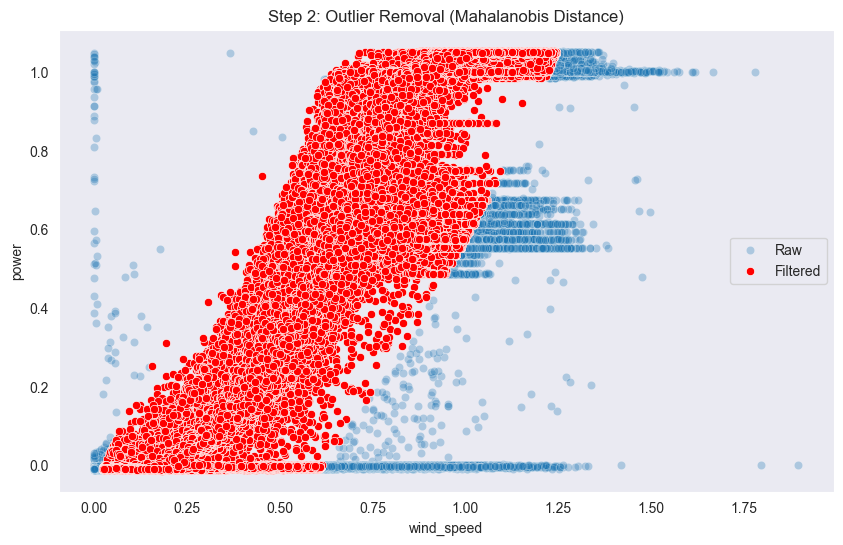

In [4]:
# ===== STEP 2: Outlier filtering (Mahalanobis) =====
def filter_outliers(df, variables, threshold=3.0):
    cov = np.cov(df[variables].T)
    inv_cov = np.linalg.inv(cov)
    mean = np.mean(df[variables], axis=0)
    distances = [mahalanobis(row, mean, inv_cov) for _, row in df[variables].iterrows()]
    return df[np.array(distances) < threshold]

variables_to_filter = ['power', 'wind_speed']
filtered = filter_outliers(data, variables_to_filter, threshold=3.0)

print(f"[Step 2] Mahalanobis filter kept {filtered.shape[0]} / {data.shape[0]} ({100*filtered.shape[0]/data.shape[0]:.1f}%)")

plt.figure(figsize=(10, 6))
sns.scatterplot(x='wind_speed', y='power', data=data, label='Raw', alpha=0.3)
sns.scatterplot(x='wind_speed', y='power', data=filtered, label='Filtered', color='red')
plt.title('Step 2: Outlier Removal (Mahalanobis Distance)')
plt.legend()
plt.grid()
plt.show()

In [5]:
# ===== STEP 3: Define healthy learn set =====
# Try a minimal healthy filter first
healthy = filtered[
    (filtered['errorcode'] == 0) &
    (filtered['wind_speed'] > 2)  # minimal cut-in limit
].copy()

# If nothing left, fallback to first part of filtered dataset
if healthy.empty:
    print("[Warning] No rows matched healthy filter — using first 25% of filtered data for training baseline.")
    healthy = filtered.iloc[:int(len(filtered) * (1 - TEST_SIZE))].copy()

# Split into learn/test
split_idx = int(len(healthy) * (1 - TEST_SIZE))
learn_df = healthy.iloc[:split_idx].copy()
test_df = filtered.iloc[split_idx:].copy()  # keep anomalies in test

# Candidate variables
candidates = [
    'wind_speed', 'generator_speed', 'rotor_speed',
    'gear_pressure', 'hydraulic_pressure', 'temp_hydraulic_oil',
    'power', 'bearing_temperature', 'generator_temperature', 'temp_environment'
]
candidates = [c for c in candidates if c in learn_df.columns]

# Fill NaNs in learn set with median values (so we don't drop all rows)
learn_df[candidates] = learn_df[candidates].fillna(learn_df[candidates].median())

# Drop NaNs from test set for required features
test_df = test_df.dropna(subset=candidates, how='any')

print(f"[Step 3] Learn set size: {len(learn_df)}, Test set size: {len(test_df)}")


[Warning] No rows matched healthy filter — using first 25% of filtered data for training baseline.
[Step 3] Learn set size: 284836, Test set size: 221540


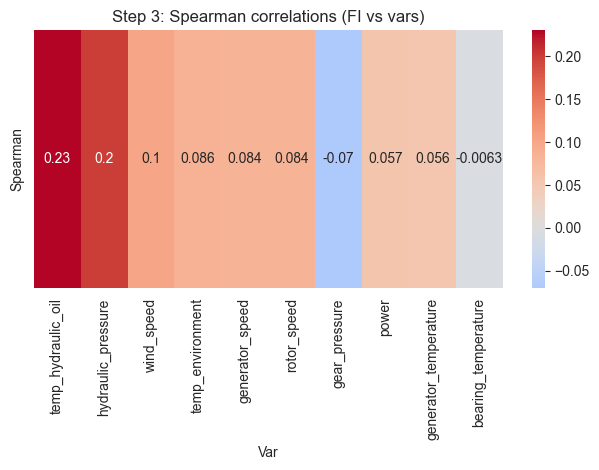

[Step 3] Selected features: ['temp_hydraulic_oil', 'hydraulic_pressure', 'wind_speed', 'temp_environment', 'generator_speed', 'rotor_speed', 'gear_pressure']


In [6]:
# ===== STEP 4: Preliminary FI to rank features =====
scaler = StandardScaler()
Xs = scaler.fit_transform(learn_df[candidates])
U = np.empty_like(Xs)
for j in range(Xs.shape[1]):
    r = rankdata(Xs[:, j], method='average')
    U[:, j] = (r - 0.5) / Xs.shape[0]
U = np.clip(U, 1e-6, 1 - 1e-6)
Z = norm.ppf(U)
gmm = GaussianMixture(n_components=3, covariance_type='full', random_state=RANDOM_STATE)
gmm.fit(Z)
logp = gmm.score_samples(Z)
FI = (1.0 - ((rankdata(logp) - 0.5) / len(logp))) * 100

# Spearman correlations
corrs = []
for col in candidates:
    rho, _ = spearmanr(FI, learn_df[col])
    corrs.append((col, rho))
corrs.sort(key=lambda x: -abs(x[1]))

sns.heatmap(pd.DataFrame(corrs, columns=['Var', 'Spearman']).set_index('Var').T,
            annot=True, cmap='coolwarm', center=0)
plt.title("Step 3: Spearman correlations (FI vs vars)")
plt.tight_layout()
plt.show()

selected_features = [c for c, _ in corrs[:TOP_K]]
print(f"[Step 3] Selected features: {selected_features}")

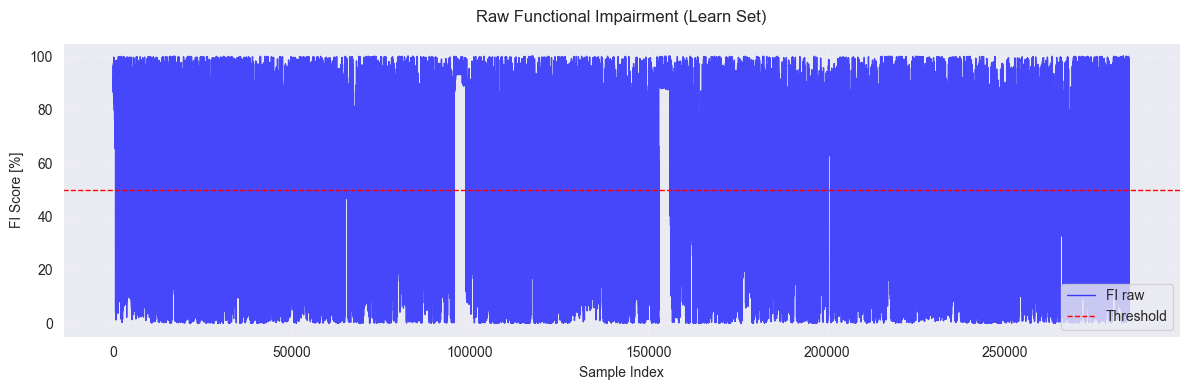

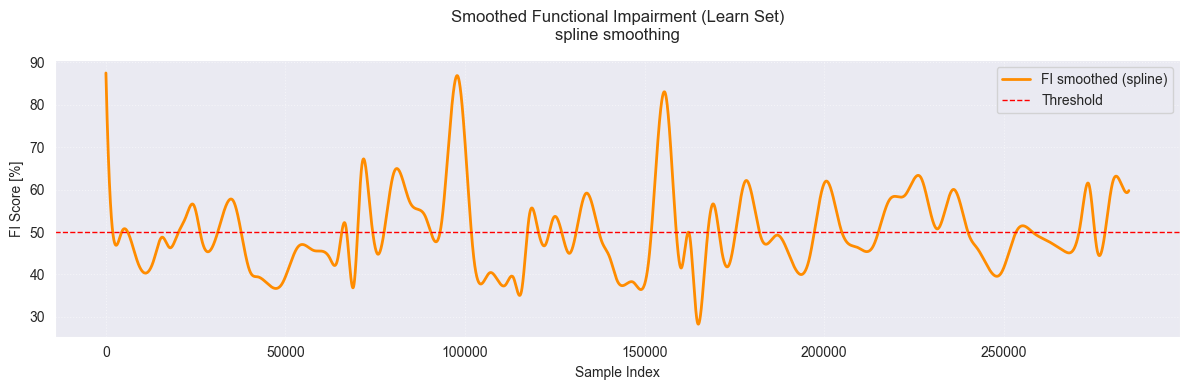

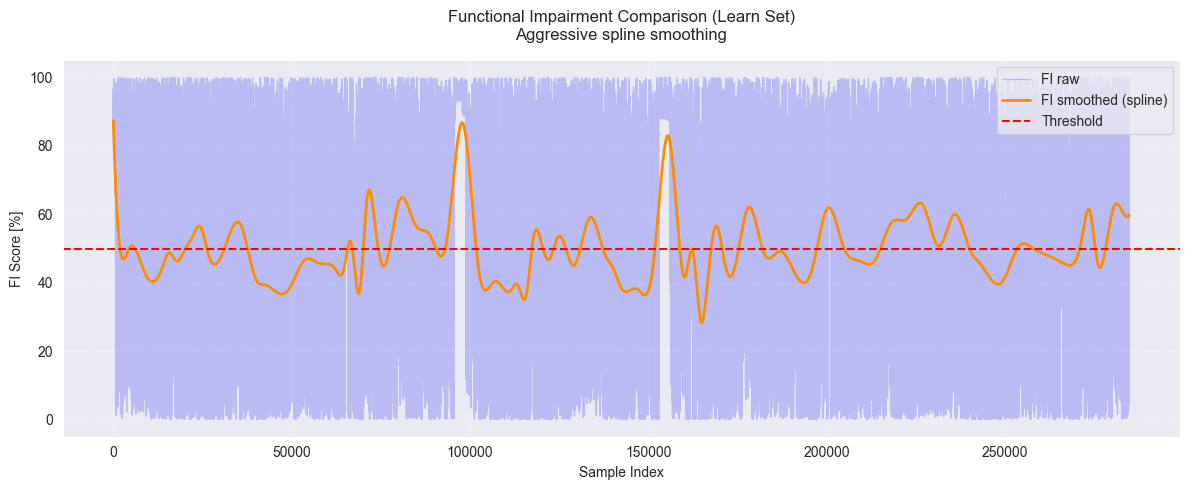


[Step 5] Aggressive Smoothing Parameters:
- Method: spline
- Spline smoothing factor: 213627000.0 (10x stronger than before)

Smoothing Effectiveness:
- Mean absolute difference between raw/smoothed: 23.31%
- Max smoothed value: 87.4% vs raw max: 100.0%
- Min smoothed value: 28.3% vs raw min: 0.0%


In [7]:
# ===== STEP 5: Final FI calculation with aggressive smoothing =====
learn_clean = learn_df[selected_features]
test_clean = test_df[selected_features]

# Standardize data
scaler = StandardScaler()
Xs_learn = scaler.fit_transform(learn_clean)
Z_learn = norm.ppf(np.clip((rankdata(Xs_learn, axis=0) - 0.5) / Xs_learn.shape[0], 1e-6, 1 - 1e-6))

# Fit GMM model
gmm = GaussianMixture(n_components=3, covariance_type='full', random_state=RANDOM_STATE)
gmm.fit(Z_learn)

# Calculate FI scores
logp_learn = gmm.score_samples(Z_learn)
FI_learn = (1.0 - ((rankdata(logp_learn) - 0.5) / len(logp_learn))) * 100

Xs_test = scaler.transform(test_clean)
Z_test = norm.ppf(np.clip((rankdata(Xs_test, axis=0) - 0.5) / Xs_test.shape[0], 1e-6, 1 - 1e-6))
logp_test = gmm.score_samples(Z_test)
FI_test = (1.0 - ((rankdata(logp_test) - 0.5) / len(logp_test))) * 100

# ===== Aggressive Smoothing Configuration =====
SMOOTHING_METHOD = 'spline'  # 'spline' or 'savgol'
SPLINE_SMOOTHING_FACTOR = len(FI_learn) * np.var(FI_learn) * 0.9  # 10x stronger than before
SAVGOL_WINDOW = 301  # Much larger window for stronger smoothing
SAVGOL_ORDER = 3

if SMOOTHING_METHOD == 'spline':
    # Cubic spline smoothing with aggressive parameters
    spl_learn = UnivariateSpline(np.arange(len(FI_learn)), FI_learn, k=3, s=SPLINE_SMOOTHING_FACTOR)
    FI_learn_s = spl_learn(np.arange(len(FI_learn)))

    spl_test = UnivariateSpline(np.arange(len(FI_test)), FI_test, k=3, s=SPLINE_SMOOTHING_FACTOR)
    FI_test_s = spl_test(np.arange(len(FI_test)))
else:
    # Strong Savitzky-Golay smoothing
    FI_learn_s = savgol_filter(FI_learn, window_length=SAVGOL_WINDOW, polyorder=SAVGOL_ORDER)
    FI_test_s = savgol_filter(FI_test, window_length=SAVGOL_WINDOW, polyorder=SAVGOL_ORDER)

# ===== Separate Raw vs Smoothed Plots =====
# Plot 1: Raw FI only
plt.figure(figsize=(12, 4))
plt.plot(FI_learn, color='blue', alpha=0.7, linewidth=1, label='FI raw')
plt.axhline(FI_THRESHOLD, color='red', linestyle='--', linewidth=1, label='Threshold')
plt.title("Raw Functional Impairment (Learn Set)", pad=15)
plt.ylabel('FI Score [%]')
plt.xlabel('Sample Index')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

# Plot 2: Smoothed FI only
plt.figure(figsize=(12, 4))
plt.plot(FI_learn_s, color='darkorange', linewidth=2, label=f'FI smoothed ({SMOOTHING_METHOD})')
plt.axhline(FI_THRESHOLD, color='red', linestyle='--', linewidth=1, label='Threshold')
plt.title(f"Smoothed Functional Impairment (Learn Set)\n{SMOOTHING_METHOD} smoothing", pad=15)
plt.ylabel('FI Score [%]')
plt.xlabel('Sample Index')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

# Plot 3: Combined view with transparency
plt.figure(figsize=(12, 5))
plt.plot(FI_learn, color='blue', alpha=0.2, linewidth=1, label='FI raw')
plt.plot(FI_learn_s, color='darkorange', linewidth=2, label=f'FI smoothed ({SMOOTHING_METHOD})')
plt.axhline(FI_THRESHOLD, color='red', linestyle='--', linewidth=1.5, label='Threshold')
plt.title(f"Functional Impairment Comparison (Learn Set)\nAggressive {SMOOTHING_METHOD} smoothing", pad=15)
plt.ylabel('FI Score [%]')
plt.xlabel('Sample Index')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

# ===== Diagnostic Output =====
print("\n[Step 5] Aggressive Smoothing Parameters:")
print(f"- Method: {SMOOTHING_METHOD}")
if SMOOTHING_METHOD == 'spline':
    print(f"- Spline smoothing factor: {SPLINE_SMOOTHING_FACTOR:.1f} (10x stronger than before)")
else:
    print(f"- SavGol window: {SAVGOL_WINDOW} (very large for heavy smoothing)")
    print(f"- SavGol polynomial order: {SAVGOL_ORDER}")

# Calculate difference metrics
smooth_diff = np.mean(np.abs(FI_learn_s - FI_learn))
print(f"\nSmoothing Effectiveness:")
print(f"- Mean absolute difference between raw/smoothed: {smooth_diff:.2f}%")
print(f"- Max smoothed value: {np.max(FI_learn_s):.1f}% vs raw max: {np.max(FI_learn):.1f}%")
print(f"- Min smoothed value: {np.min(FI_learn_s):.1f}% vs raw min: {np.min(FI_learn):.1f}%")

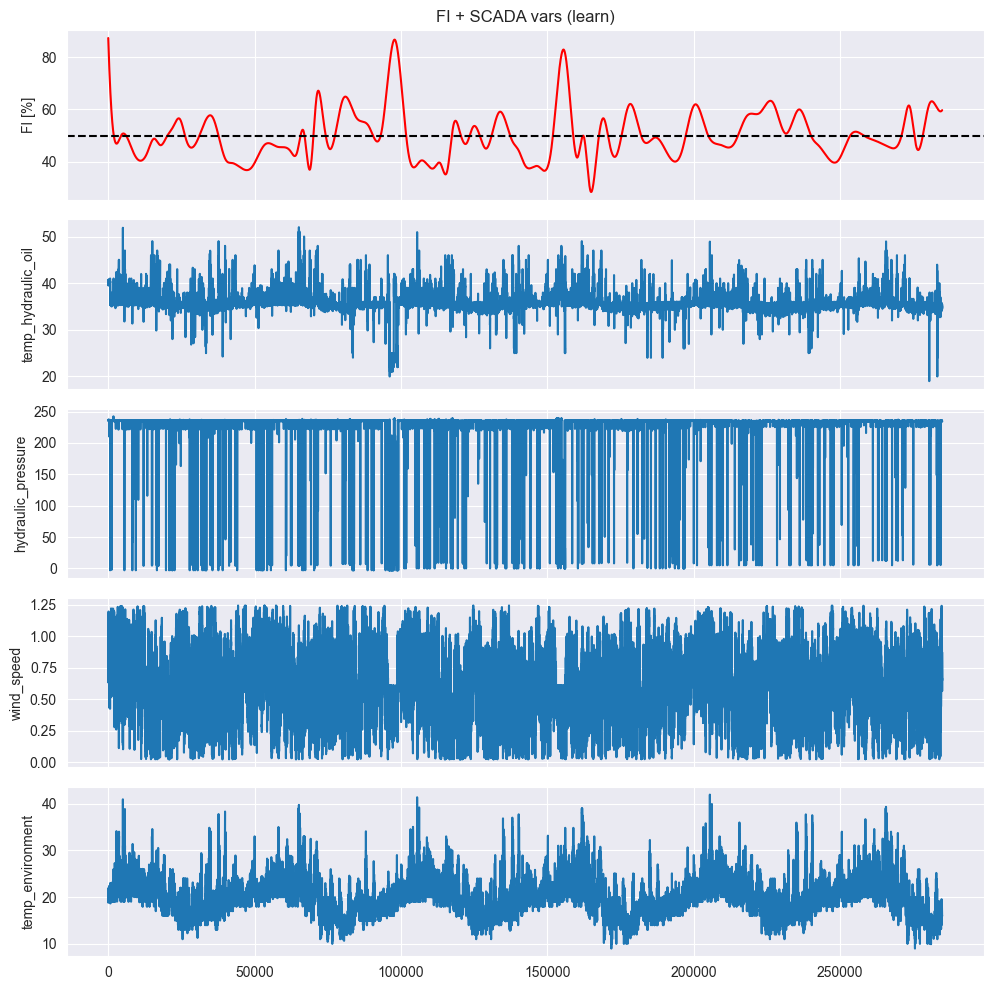

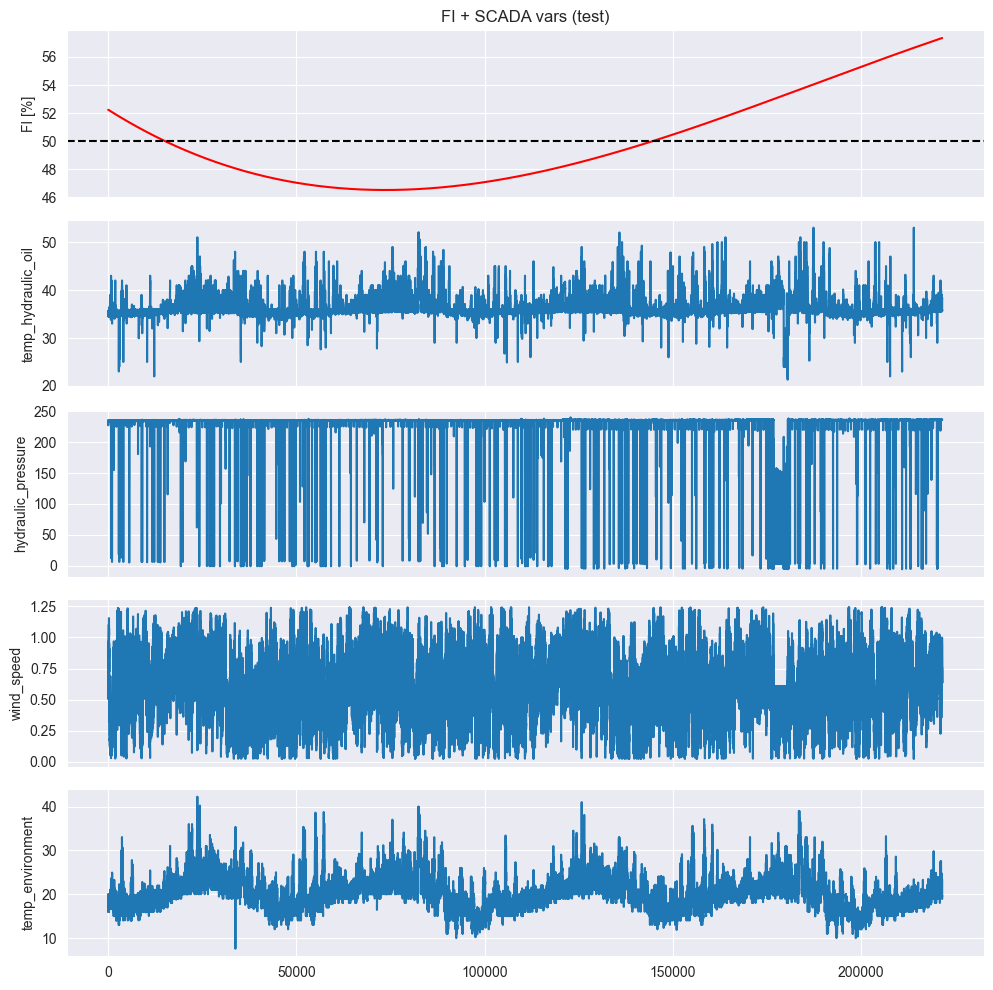

In [8]:
# ===== STEP 6: FI + SCADA variables (raw values) =====
nvars = min(4, len(selected_features))
fig, axes = plt.subplots(nvars+1, 1, figsize=(10, 2*(nvars+1)), sharex=True)
axes[0].plot(FI_learn_s, color='red')
axes[0].axhline(FI_THRESHOLD, linestyle='--', color='black')
axes[0].set_ylabel('FI [%]')
axes[0].set_title("FI + SCADA vars (learn)")
for i, var in enumerate(selected_features[:nvars], start=1):
    axes[i].plot(learn_df[var].values)  # raw values from learn_df
    axes[i].set_ylabel(var)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(nvars+1, 1, figsize=(10, 2*(nvars+1)), sharex=True)
axes[0].plot(FI_test_s, color='red')
axes[0].axhline(FI_THRESHOLD, linestyle='--', color='black')
axes[0].set_ylabel('FI [%]')
axes[0].set_title("FI + SCADA vars (test)")
for i, var in enumerate(selected_features[:nvars], start=1):
    axes[i].plot(test_df[var].values)  # raw values from test_df
    axes[i].set_ylabel(var)
plt.tight_layout()
plt.show()